# 05 Model Comparison

Compare LightGBM and XGBoost using standardized OOF predictions, metrics, and timing.

In [1]:
from pathlib import Path
import sys
import json

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT / "src"))

from amex_default.config import ACTIVE_MODELS, MODEL_COMPARISON_PATH, PLOTS_DIR, PREDICTIONS_DIR, REPORTS_DIR
from amex_default.evaluate import (
    comparison_from_metrics,
    evaluate_oof_frame,
    plot_metric_comparison,
    save_evaluation_plots,
    save_metrics_report,
    save_oof_frame,
    standardize_oof_frame,
)


In [2]:
metrics_by_model = []

for model_name in ACTIVE_MODELS:
    raw_oof = pd.read_parquet(PREDICTIONS_DIR / f"{model_name}_oof.parquet")
    oof = standardize_oof_frame(raw_oof, model_name)
    save_oof_frame(oof, PREDICTIONS_DIR / f"{model_name}_oof.parquet")

    metrics_path = REPORTS_DIR / f"{model_name}_metrics.json"
    existing_metrics = json.loads(metrics_path.read_text()) if metrics_path.exists() else {}
    metrics = evaluate_oof_frame(
        oof,
        model_name,
        training_time_seconds=existing_metrics.get("training_time_seconds"),
        inference_time_seconds=existing_metrics.get("inference_time_seconds"),
        n_features=existing_metrics.get("n_features"),
        fold_metrics=existing_metrics.get("fold_metrics"),
    )
    save_metrics_report(metrics, metrics_path)
    save_evaluation_plots(oof, model_name, PLOTS_DIR)
    metrics_by_model.append(metrics)

comparison = comparison_from_metrics(metrics_by_model)
comparison.to_csv(MODEL_COMPARISON_PATH, index=False)
comparison.to_csv(REPORTS_DIR / "model_comparison.csv", index=False)
display(comparison.sort_values("roc_auc", ascending=False))


,model,n_rows,n_features,roc_auc,pr_auc,precision,recall,f1,threshold,training_time_seconds,inference_time_seconds,total_time_seconds
1,xgboost,229456,3418,0.959721,0.894806,0.812402,0.803514,0.807934,0.5,4996.370889,0.418710,4996.789599
0,lightgbm,229456,3418,0.959328,0.893820,0.810382,0.805854,0.808112,0.5,901.473069,1.775503,903.248572


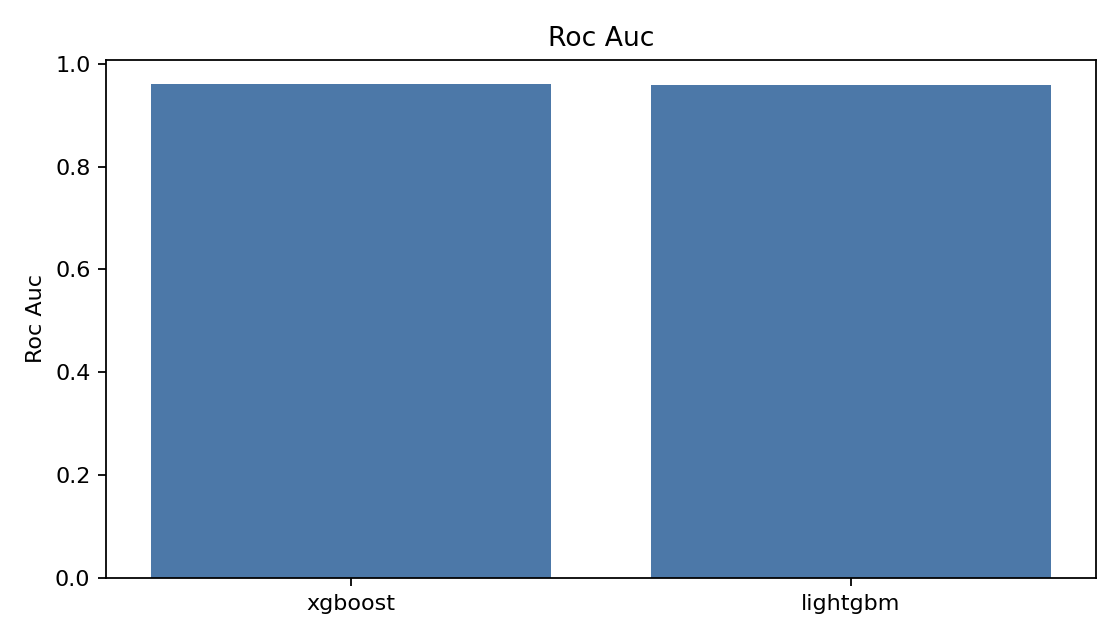

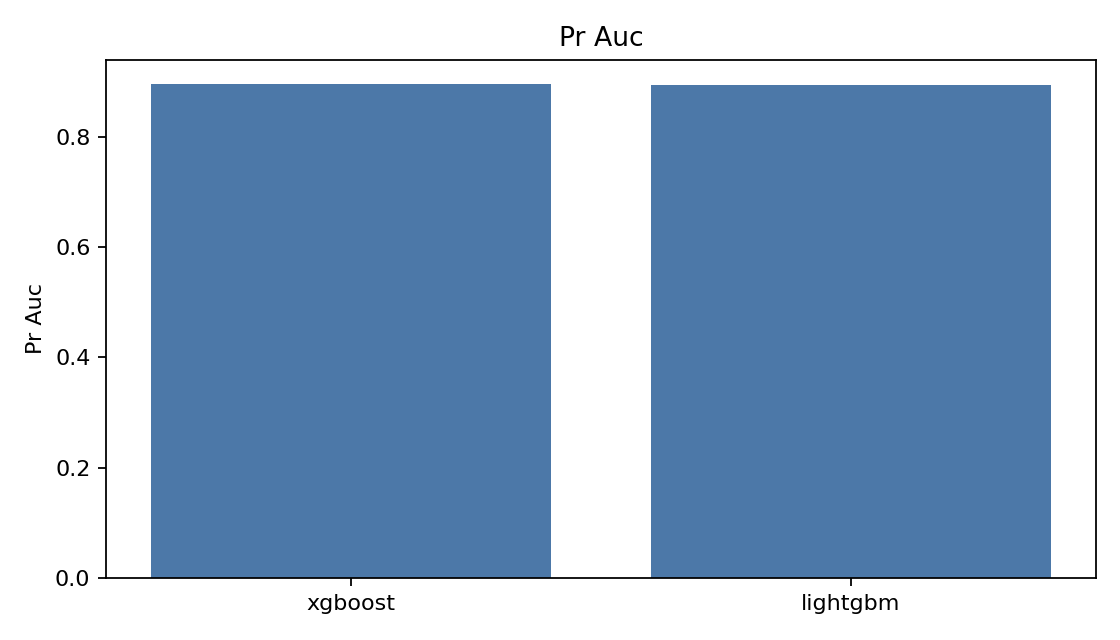

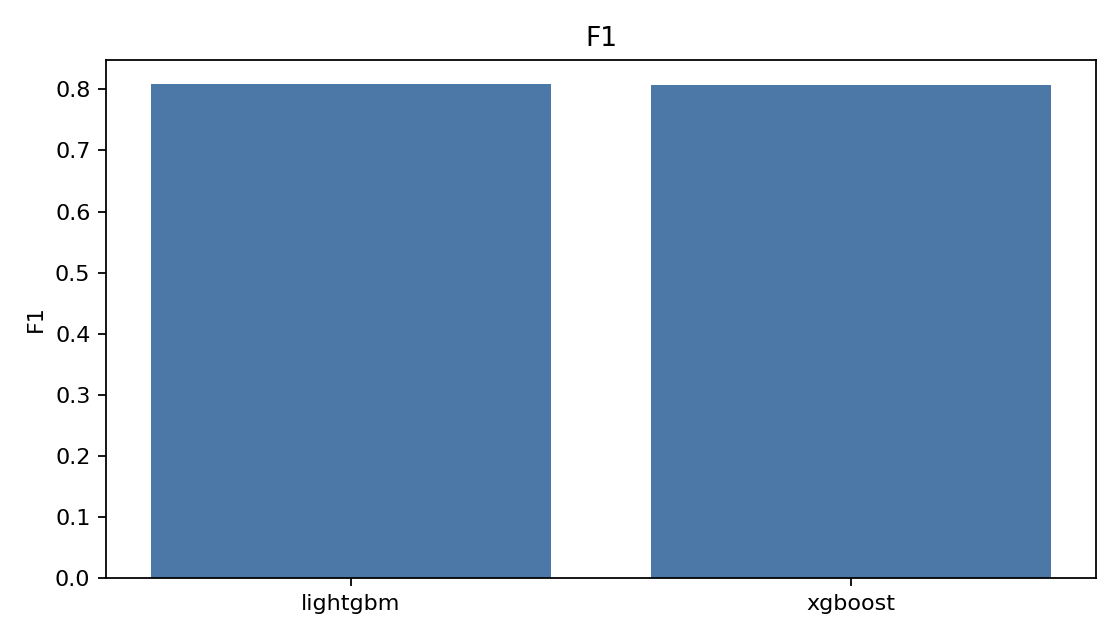

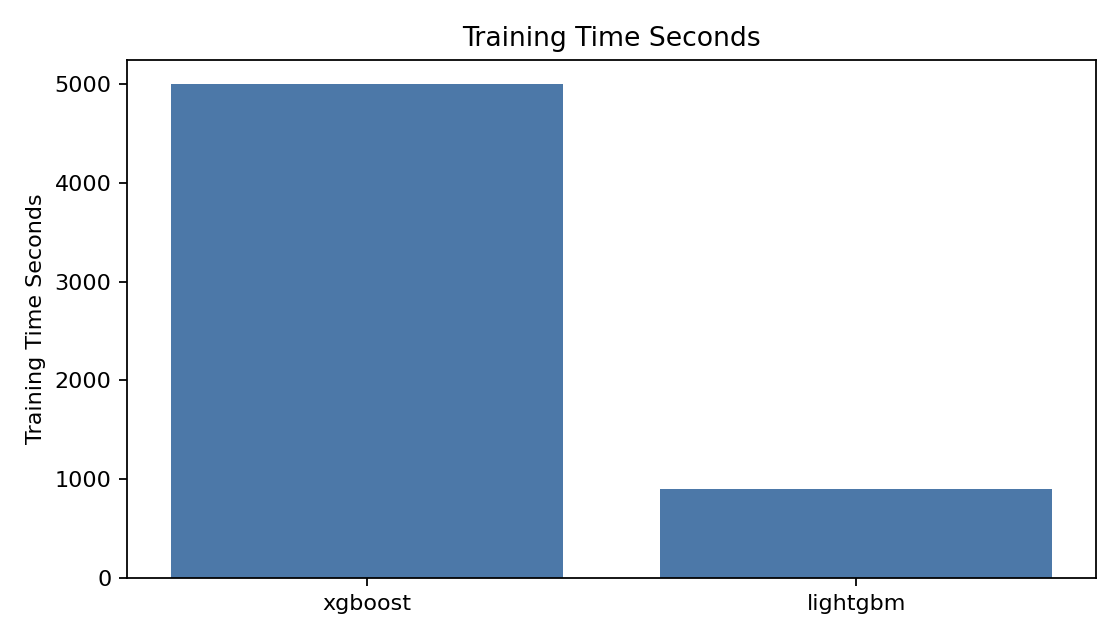

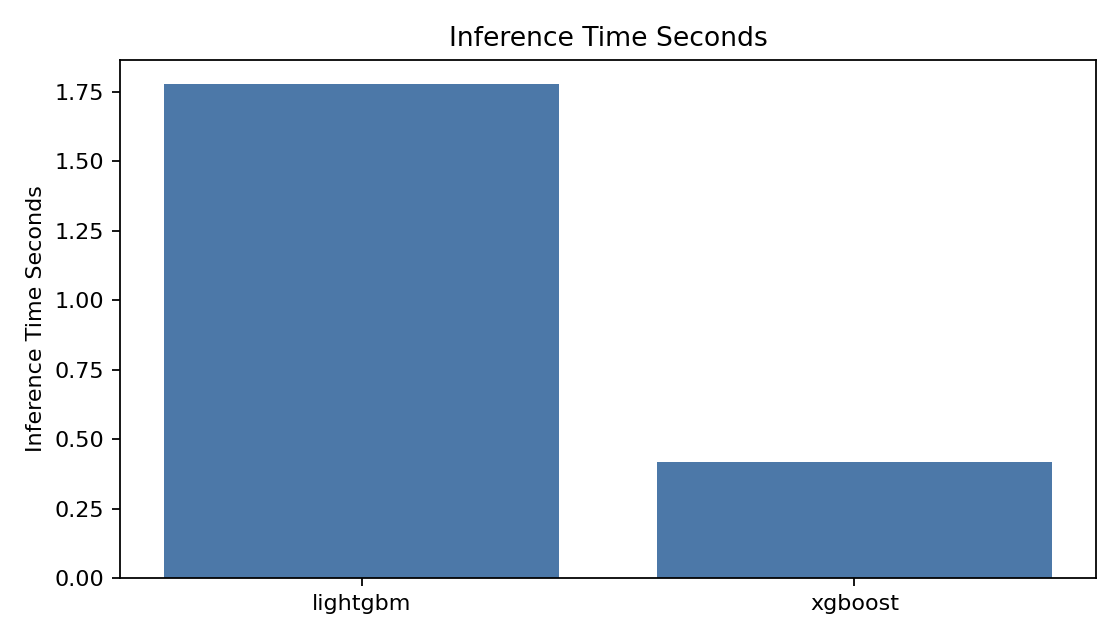

In [3]:
plot_files = {
    "roc_auc": ["model_comparison_roc_auc.png", "model_comparison_auc.png"],
    "pr_auc": ["model_comparison_pr_auc.png"],
    "f1": ["model_comparison_f1.png"],
    "training_time_seconds": ["model_comparison_training_time_seconds.png"],
    "inference_time_seconds": ["model_comparison_inference_time_seconds.png"],
}

shown = []
for metric, filenames in plot_files.items():
    if comparison[metric].notna().any():
        for filename in filenames:
            plot_metric_comparison(comparison, metric, PLOTS_DIR / filename)
        shown.append(filenames[0])

for filename in shown:
    display(Image(filename=str(PLOTS_DIR / filename)))
